<center>
<font color='blue'/><h1 style="text-align:center; color:red"> ISAT 341: Machine Learning and Data Science with Python </h1>
</center>
<img src="pixel_image_of_the_number_2.png" width=150; height=150 align='center'>

<center> 
    <font color='blue'/><h2 style="text-align:center; color:blue";>Lab 10-Image Recognition and Classification of Imported Data</h2>
<h3 style="text-align:center; color:blue";>(Supervised Learning: Classification of the SciKit Learn Digits Dataset) </h3>
    
</center>

In [1]:
%matplotlib inline


# Recognizing hand-written digits


### A lab showing how the scikit-learn can be used to recognize images of hand-written digits.


## Introduction
### The digits dataset in SciKit Learn
* This dataset is made up of 1797 images.
* Each image, like the one shown below, is of a hand-written digit 
* Each image is an 8 by 8 pixel square (64 pixels total).


## Objectives
### Image Recognition and Classification (Digits Dataset)
* Create and use Machine Learning Models with SciKit Learn
* Learn more advanced NumPy (Numerical Python) features
* Learn how to import and use SciKit Learn built-in datasets (digits dataset)
* Understand shape of the image data
* Transform (reshape)image dataset on NumPy Arrays
* Train-Test Split of data with SciKit Learn
* Perform Classification with SciKit Learn
* Create Predictive Models
* Perform Model Evaluation
    * Model Score and Accuracy
    * Confusion Matrix


## Data and Problem Description

The problem we are studying is a digit recognition and classification task. This means that there are 10 digits (ranging from 0 to 9) so that we have 10 classes to predict. This is called a multiclass prediction problem. In order to utilize an 8x8 figure like this, we’d have to first transform it into a feature vector with length 64. This is done by **flattening** the image so that we can apply a classifier on this data. This flattening will allow us to create a dataset consisting a (samples, feature) matrix:

### Machine learning on the digits dataset
- The problem is framed as a supervised learning problem: Predict the integer value of a hand written digit using the transformed image set.

- A standard split of the dataset is used to evaluate and compare models
- A subset of images is used to train a model and a separate set of images are used to test it.

#### COMMENT: 
The training dataset is structured as a 3-dimensional array of instance, image width and image height. For a classification model we must reduce the images down into a vector of pixels. For the case we are considering, the 8×8 sized images will be 64 pixel input values. We can do this transformation easily using the reshape() function on the NumPy array. We can also reduce our memory requirements by forcing the precision of the pixel values to be 32 bit.

**However**, scikit-learn provides two ways of accessing the image dataset:
 1. either as aset of 8 x 8 arrays 
 2. as already flattened 64 pixel vectors

We will have occasion to use both formats.


### Imports and Loading Scikit-learn's built-in image dataset: digits

In [2]:
# Standard scientific Python imports
import matplotlib.pyplot as plt
import numpy as np

# Import datasets
from sklearn import datasets
# Load the digits dataset
digits = datasets.load_digits()

### Print some info on digits dataset

In [3]:
# different storage formats
print("The digits are numpy arrays as can be seen here: {}".format(type(digits.images[0])))
print('Note the shape of the images: {}'.format(digits.images.shape))
print('Also, scikit-learn also has an already flatttened version of the images: {}'.format( digits.data.shape))
print('Here,we  also display the target vector {}'.format(digits.target))

The digits are numpy arrays as can be seen here: <class 'numpy.ndarray'>
Note the shape of the images: (1797, 8, 8)
Also, scikit-learn also has an already flatttened version of the images: (1797, 64)
Here,we  also display the target vector [0 1 2 ... 8 9 8]


You should take note from the output from `digits.images.shape` that the dataset is structured as a 3-dimensional array of instance, image width and image height. To apply a classifier on this data, we need to flatten the image, to turn the data into a (samples, feature) matrix. This easily done using *numpy* or the already flattended images conveninently supplied by scikit-learn

#### <font color='blue'/> If we print the dataset keys and description we can leran more about the structure of the images and how they are stored. 

In [4]:
print('Keys of the digits dataset: \n{}'.format(digits.keys()))

Keys of the digits dataset: 
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [5]:
print('\n',digits['DESCR'][:300] + '\n...')


 .. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 1797
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Miss
...


<font color='blue'/> Scikit-Learn uses a **Bunch object** to store images and other data. A **Bunch object** is a <em> "Container object exposing keys as attributes."</em>
Bunch objects are sometimes used as an output for functions and methods. They extend dictionaries by enabling values to be accessed by key, bunch["value_key"], or by an attribute, bunch.value_key.

<font color='black'/>
<p>
    
You should make sure you understand the two shapes that you can use when you load the images. Let's just load the first image using these formats.
</p>

### <font color='blue'/> Load image data as a 64 column feature vector:

In [6]:
print('You can use either the dictionary format to retrieve a digit\n {}'.format(digits['data'][0]))
print(' OR you can acces the data using the bunch.value_key approach\n {}'.format(digits.data[0]))

You can use either the dictionary format to retrieve a digit
 [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
 OR you can acces the data using the bunch.value_key approach
 [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


### <font color='blue'/> Load image data as an 8 x 8 array:

In [7]:
print('You can use either the dictionary format to retrieve a digit\n {}'.format(digits['images'][0]))
print(' OR you can acces the data using the bunch.value_key approach\n {}'.format(digits.images[0]))

You can use either the dictionary format to retrieve a digit
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
 OR you can acces the data using the bunch.value_key approach
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


The numercal values indicate the *intensity* of the pixels that represent the image. In the case of the built-in scikit-learn handwritten digits, the intensities range from zero (dark) to sixteen (bright). It is convenient and useful to normalize the pixel intensities so that they range for 0 to 1, which we will do below. Before we do, let's display an image.

### <font color='blue'/> Displaying images
Here we display an image using the *images* key  so that we get an 8 x 8 2D array which is the required shape if we want to display an image. We can display the image using matplotlib's `imshow`  method:

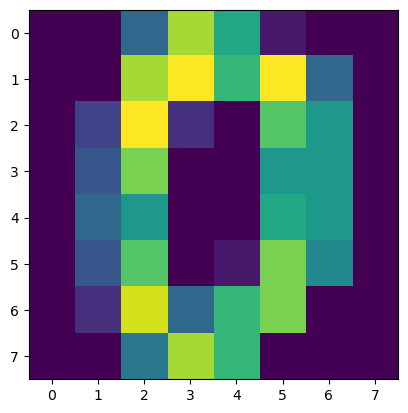

In [8]:
#display image already in image format
i=0
plt.imshow(digits.images[i])

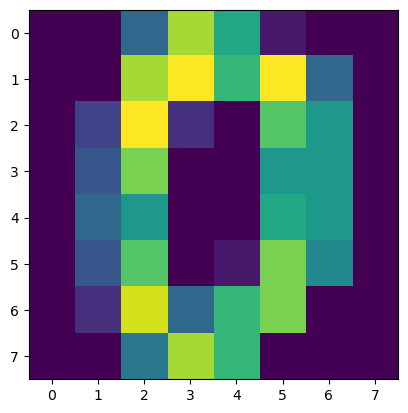

In [9]:
#display image from data that need to be reshaped
i=0
plt.imshow(digits.data[i].reshape(8,8))

The data that we are interested in is made of 8x8 images of digits, let's have a look at the first 4 images, stored in the `images` attribute of the dataset. 

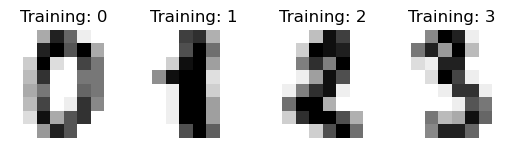

In [10]:
#zip images and label together
images_and_labels = list(zip(digits.images, digits.target))
#loop and display 4 images in grayscale
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: {}'.format(label))

If we were working from image files, we could load them using **matplotlib.pyplot.imread**. Note that each image must have the same size. For these images, we know which digit they represent: it is given in the 'target' of the dataset.

### Create the feature matrix  and target vector

First let get the data using the `data` atrribute for the images and create our feature matrix. We also will create our target vector.

In [11]:
# Create feature matrix- This is all of the images in the dataaset
X = digits.data

# Create target vector
y = digits.target

### Normalize the data for better fitting and convergence

In [12]:
#before normalization
X.max(), X.min()

(16.0, 0.0)

In [13]:
X = X/16.0

In [14]:
#after normalization
X.max(), X.min()

(1.0, 0.0)

### Model Training: Training and Testing Data
###  *Test/train splits of data*
Scikit learn contains a function called the **train_test_split** function  that will randomly shuffle the dataset and then splits it into two datasets: a **training set** used to build the model and a **test set** to assess and evaluate how well the model works on unseen data (also called out-of-sample data). The train_test_split function by default does a 75%/25% train/test split but the split can be modified by tuning the parameters of the function as indicated below in the code.Let's do an 80%/20% train-test split for this lab.

In [15]:
from  sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

What did this accomplish?

- **NOTE** that we are using the *data* that has already been reshaped ans is suitable for our classfier!
- Model can be trained and tested on **different data**
- Response values are known for the testing set, and thus **predictions can be evaluated**
- **Testing accuracy** is a better estimate than training accuracy of out-of-sample performance

We also want to look at the **shape of the data** and the **proportions** of the training set (*after the split*) that will be used for training the classifier on each **unique** class label (*digit*). We use Numpy(*see below*) to examinie the unique clss label and the bins (actually the bin count) that the training set has been allocated to.

In [16]:
print('X_train Shape of the data : {}'.format(X_train.shape))
print('y_train Shape of the data : {}'.format(y_train.shape))

X_train Shape of the data : (1437, 64)
y_train Shape of the data : (1437,)


In [17]:
print('X_test Shape of the data : {}'.format(X_test.shape))
print('y_test Shape of the data : {}'.format(y_test.shape))

X_test Shape of the data : (360, 64)
y_test Shape of the data : (360,)


### Check for Balanced Dataset

Class labels: [0 1 2 3 4 5 6 7 8 9]
Class proportions: [151 147 141 154 151 142 137 140 135 139]


<BarContainer object of 10 artists>

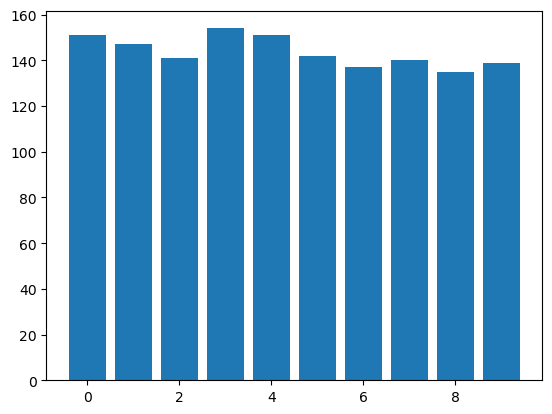

In [18]:
print('Class labels:', np.unique(y_train))
print('Class proportions:', np.bincount(y_train))
plt.bar(np.unique(y_train),np.bincount(y_train))

## Building (Fitting) and Evaluating the Models

Let's build the actual machine learning models.  There are several classification algorithms avaialble in the scikit-learn package and we will restrict our two widley used classifiers:
* Logistic Regression
* Support Vector Machine (HW Assignment!)


All of the machine learning models in sckit-learn are implemented in their own classes called Estimator Classes. Each model has its advantages and we will determine how well each model works through model evaluation metrics

### Fitting the Model using a Logistic Regression Classifier
Import and instantiate the classifier

In [19]:
from sklearn.linear_model import LogisticRegression
# Create a classifier: instantiate the model to create a linear Regression classifier
lr = LogisticRegression(solver='newton-cg', 
                        multi_class='multinomial', 
                        random_state=0)

### Train the model by fitting the data

In [20]:
# Train the model by fitting the data
# We "learn" the digits on this set of training data from all of the images
lr.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg')

### Let's Evaluate the  Logistic Regression Classifier Model

We do this by using the **test set** that we created earlier. Note that this data *was not* used to build (train) the model, but we do know what the digits are (correct class labels) for each image in the test set. Thus, we can make a prediction for each image  in the test data and compare it to its known class label (**known digit**). We can measure how well the model works by computing the model's *accuracy*, which is the fraction of images for which the right digit was predicted.

Let's Proceed: We will feed the test set of data into the classifier's predictor method and have it predict what the output digit is for each input image of the test set. The number of responses we get will be equal to the number of input images in the test set. 

### Predictions on test set

In [21]:
# Now predict the value of the digits on the test set data:
y_pred = lr.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))

Test set predictions:
 [2 8 2 6 6 7 1 9 8 5 2 8 6 6 6 6 1 0 5 8 8 7 8 4 7 5 4 9 2 9 4 7 6 8 9 4 3
 1 0 1 8 6 7 7 1 0 7 6 2 1 9 6 7 9 0 0 9 1 6 3 0 2 3 4 1 9 2 6 9 1 8 3 5 1
 2 8 2 2 9 7 2 3 6 0 5 3 7 5 1 2 9 9 3 1 4 7 4 8 5 8 5 5 2 5 9 0 7 1 4 4 3
 4 8 9 7 9 8 2 1 5 2 5 8 4 1 7 0 6 1 5 5 9 9 5 9 9 5 7 5 6 2 8 6 9 6 1 5 1
 5 9 9 1 5 3 6 1 8 9 8 7 6 7 6 5 6 0 8 8 9 8 6 1 0 4 1 6 3 8 6 7 4 9 6 3 0
 3 3 3 0 7 7 5 7 8 0 7 1 9 6 4 5 0 1 4 6 4 3 3 0 9 5 9 2 9 4 2 1 6 8 9 2 4
 9 3 7 6 2 3 3 1 6 9 3 6 3 2 2 0 7 6 1 1 9 7 2 7 8 5 5 7 5 2 3 7 2 7 5 5 7
 0 9 1 6 5 9 7 4 3 8 0 3 6 4 6 3 2 6 8 8 8 4 6 7 5 2 4 5 3 2 4 6 9 4 5 4 3
 4 6 2 9 0 6 7 2 0 9 6 0 4 2 0 7 9 8 5 7 8 2 8 4 3 7 2 6 9 1 5 1 0 8 2 8 9
 5 6 2 2 7 2 1 5 1 6 4 5 0 9 4 1 1 7 0 8 9 0 5 4 3 8 8]


### Accuracy score

In [22]:
print("Test set score: {0:0.2f}".format(np.mean(y_pred==y_test)))

Test set score: 0.96


We can also use the score method of the lsvc object, which will compute the test set score accuracy for us: 

In [23]:
print("Test set score (accuracy on test set): {0:0.2f}".format(lr.score(X_test,y_test)))

Test set score (accuracy on test set): 0.96


A mean score of approximately 0.96 is really excellent. A further statistic is the confusion matrix that shows the errors that the classifier made during training.

### Classification Report

In [24]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.91      0.91      0.91        35
           2       0.97      1.00      0.99        36
           3       1.00      1.00      1.00        29
           4       0.94      0.97      0.95        30
           5       0.97      0.95      0.96        40
           6       0.98      0.98      0.98        44
           7       0.97      0.95      0.96        39
           8       0.97      0.92      0.95        39
           9       0.93      0.98      0.95        41

    accuracy                           0.96       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.96      0.96      0.96       360



### Confusion Matrix

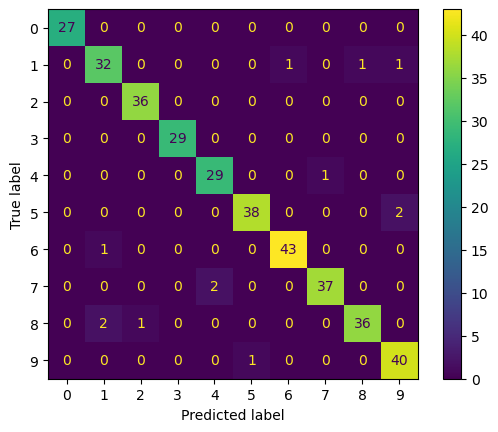

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=lr.classes_)
disp.plot()

plt.show()

### Predictions with images

#### NOTE: Below I had to *temporarily* reshape the X_test data back into 8 x 8 image arrays so that matplotlib could display them using ` imshow()`

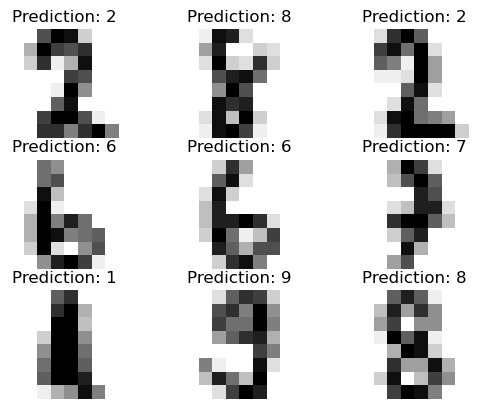

In [26]:
# zip images and predictions for the test set data
images_and_predictions = list(zip(X_test.reshape(len(X_test),8,8), y_pred))
#display the first 9 predictions and the true images
for index, (image, prediction) in enumerate(images_and_predictions[:9]):
    plt.subplot(3, 3, index + 1 )
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Prediction: {}'.format(prediction))

plt.show()

### <font color='orange'/>Questions
#####  <font color='red'/>Please use ONE CELL for each answer

### <font color='green'/> Q1 (5 points): Display a predicted image and it's corresponding true value
Use your prediction vector from above, y_pred, to display the prediction for a *single* image.  Also print the true value from the test set. Select the test set image with index = 21 for this question.

### <font color='orange'/>Answer 1

### <font color='green'/> Q2 (10 points):  Build and fit a model using Support Vector Machine classifier.
In a **single** cell below. Build and fit a model using the Support Vector Machine classifier. Use the same split of data that was used above (so you **do not** need to split the data again). Also,create a predicition vector from the test set data using this model.

The Support vector classifier has to be imported and instantiated as shown below:
```python
from sklearn import svm
svc = svm.SVC(gamma=0.01, probability=True, random_state=0)
```
After the model has been trained, in this order: 

1. display the classification accuracy 
2. print the predicition vector
3. use your predicition vector to display nine (9) predictions starting with index 12 of the test set. You may suitably modifiy the above used to didplay 9 predicted images and their corresponding true labels 

### <font color='orange'/>Answer 2

### <font color='green'/> Q3 (5 points): Class Membership Probabilities of the Support Vector Machine classifier.
Use the `predic_prpba` method to display the class membership probabilities for 41st. row of the test set data. What is the digit prediction and with what probability?

### <font color='orange'/>Answer 3

In [ ]:
np.set_printoptions(precisions)

### <font color='green'/> Q4 (BONUS-5 points): 
Earlier in the semester we created and reshaped numpy arrays. I hpoe you see why this is important when processing and displaying images. **Sometimse you see notation** like  *array.reshape(n_samples, -1)* means we want the reshaped data to have **n_samples** as the number of rows and for numpy to figure out the number of columns (features) from the remaining dimensions. For example if we had an array with dimensions 3 x 3 x 2 = 18 and we wanted to reshape it into an array with only two rows, we would put *array.reshape(2,-1)* and since the total size has to stay fixed, our array would have a new shape of 2 x 9 = 18. In the questions below, you are to let numpy figure out the dimensionin question.

- Create a numpy array with 100 zeroes (name the array *image*) and reshape it so that it has only four rows. How many columns does it have?
- Now reshape it into any 3D array with the first index being 2. You pick the second index and let Numpy figure out the last index. Print the shape of your array.

### <font color='orange'/>Answer 4 (Three lines of code ONLY, two of them being print statements)